# 1 - Imports

In [15]:
%reload_ext autoreload
%autoreload 2

In [16]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parents[0]))

In [18]:
from src.utils import templates, config, io

/Users/hippolytegrandet/Desktop/Dev/country_risk_rating/.venv/lib/python3.9/site-packages/pypdf/_crypt_providers/_cryptography.py:32: CryptographyDeprecationWarning: ARC4 has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.ARC4 and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  from cryptography.hazmat.primitives.ciphers.algorithms import AES, ARC4


# 2 - Intigration

## 2.1 - Loading Datasets

In [36]:
oecd_rating_matrix = io.load_csv(config.INTERIM_DATA_DIR / 'oecd_rating_matrix_yearly.csv', index_col=0)
oecd_rating_matrix

,1999-01-01,2000-01-01,2001-01-01,2002-01-01,2003-01-01,2004-01-01,2005-01-01,2006-01-01,2007-01-01,2008-01-01,...,2014-01-01,2015-01-01,2016-01-01,2017-01-01,2018-01-01,2019-01-01,2020-01-01,2021-01-01,2022-01-01,2023-01-01
ISO3_COUNTRY_CODE,,,,,,,,,,,,,,,,,,,,,
AFG,7,7,-,-,-,-,-,-,-,7,...,7,7,7,7,7,7,7,7,7,7
ALB,7,7,7,7,7,7,6,6,6,6,...,6,6,6,6,6,6,5,5,5,5
DZA,6,6,5,5,4,4,4,3,3,3,...,3,3,3,4,4,4,4,5,5,5
AND,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,-
AGO,7,7,7,7,7,7,7,7,7,7,...,5,5,5,6,6,6,6,6,6,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VNM,6,6,6,6,5,5,5,5,5,4,...,5,5,5,5,5,5,4,4,4,4
PSE,-,-,-,-,-,-,-,-,-,-,...,7,7,7,7,7,7,7,7,7,7
YEM,7,7,7,6,6,6,6,6,6,6,...,7,7,7,7,7,7,7,7,7,7


In [37]:
worldbank_df = io.load_csv(config.INTERIM_DATA_DIR / 'worldbank_dataset_extracted.csv', index_col=0)
worldbank_df

,NY.GDP.MKTP.CD,NY.GDP.MKTP.KD.ZG,NY.GDP.MKTP.PP.CD,NY.GDP.PCAP.CD,NY.GDP.PCAP.KD.ZG,NE.GDI.TOTL.KD.ZG,NE.GDI.TOTL.ZS,NV.IND.TOTL.CD,NV.IND.TOTL.KD.ZG,NV.IND.TOTL.ZS,...,SE.PRM.CUAT.ZS,SP.POP.DPND,SL.TLF.CACT.ZS,GE.EST,RQ.EST,IC.BRE.BI.OS,IC.BRE.BE.OS,IQ.CPA.PADM.XQ,FS.AST.PRVT.GD.ZS,FM.AST.PRVT.GD.ZS
COUNTRY_PERIOD_INDEX,,,,,,,,,,,,,,,,,,,,,
ABW-1999,1.722905e+09,1.238042,2.489441e+09,19216.197235,-0.125966,NaN,30.869001,2.678827e+08,NaN,15.548314,...,NaN,43.669781,NaN,NaN,NaN,NaN,NaN,NaN,44.620525,44.620525
AFG-1999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,108.686031,46.609,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AGO-1999,6.152923e+09,2.181490,5.669622e+10,392.725539,-1.130799,NaN,NaN,NaN,NaN,NaN,...,NaN,93.586677,77.380,NaN,NaN,NaN,NaN,NaN,NaN,2.573386
ALB-1999,3.283942e+09,12.250728,1.112055e+10,1056.344812,12.963927,31.190830,24.271511,6.082915e+08,20.139252,18.523214,...,NaN,59.064263,62.061,NaN,NaN,NaN,NaN,NaN,NaN,4.116988
AND-1999,1.240295e+09,4.099079,2.075776e+09,18875.288370,3.579455,NaN,NaN,NaN,NaN,NaN,...,NaN,37.399632,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WSM-2023,1.044910e+09,15.233611,1.775512e+09,4822.740847,14.487948,27.487930,36.068083,1.053197e+08,-1.836608,10.079316,...,NaN,79.964616,43.438,0.492577,-0.270535,NaN,NaN,4.0,74.148912,39.843664
YEM-2023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,45.513580,77.726093,33.106,-2.275420,-1.843051,NaN,NaN,1.5,NaN,NaN
ZAF-2023,3.814407e+11,0.806105,9.608114e+11,6034.272090,-0.523851,-1.777435,15.391317,9.369697e+10,-0.324993,24.563966,...,87.625877,48.367934,55.020,-0.256947,-0.223698,NaN,NaN,NaN,90.372482,57.519623


## 2.2 - Joining Datasets

In [38]:
oecd_countries = list(oecd_rating_matrix.index)
max_year = int(max(oecd_rating_matrix.columns)[:4])
template_df = templates.get_template_yearly_df(oecd_countries, last_year=max_year)
template_df

,YEAR,ISO3_COUNTRY_CODE
COUNTRY_PERIOD_INDEX,,
AFG-1999,1999,AFG
AFG-2000,2000,AFG
AFG-2001,2001,AFG
AFG-2002,2002,AFG
AFG-2003,2003,AFG
...,...,...
ZWE-2019,2019,ZWE
ZWE-2020,2020,ZWE
ZWE-2021,2021,ZWE


### 2.2.1 - Formating OECD Ratings

In [39]:
from src.preprocessing import merge_datasets

In [40]:
formated_oecd_df = merge_datasets.format_oecd_df(oecd_rating_matrix, template_df)
formated_oecd_df

,YEAR,ISO3_COUNTRY_CODE,OECD_RATING
COUNTRY_PERIOD_INDEX,,,
AFG-1999,1999,AFG,7
AFG-2000,2000,AFG,7
AFG-2001,2001,AFG,-
AFG-2002,2002,AFG,-
AFG-2003,2003,AFG,-
...,...,...,...
ZWE-2019,2019,ZWE,7
ZWE-2020,2020,ZWE,7
ZWE-2021,2021,ZWE,7


In [41]:
io.save_csv(formated_oecd_df, config.PROCESSED_DATA_DIR / 'ratings_formatted_yearly.csv', index=True)

### 2.2.2 Merging Features and Target

In [42]:
import wbgapi as wb
country_info_df = wb.economy.DataFrame(skipAggs=True)
country_info_df = country_info_df[['region', 'adminregion', 'lendingType', 'incomeLevel']]
country_info_df = country_info_df.rename(columns={
    'region': 'GEO_REGION',
    'adminregion': 'ADMIN_REGION',
    'lendingType': 'LENDING_TYPE',
    'incomeLevel': 'INCOME_GROUP',
})
country_info_df

,GEO_REGION,ADMIN_REGION,LENDING_TYPE,INCOME_GROUP
id,,,,
ABW,LCN,,LNX,HIC
AFG,MEA,MNA,IDX,LIC
AGO,SSF,SSA,IBD,LMC
ALB,ECS,ECA,IBD,UMC
AND,ECS,,LNX,HIC
...,...,...,...,...
XKX,ECS,ECA,IDX,UMC
YEM,MEA,MNA,IDX,LIC
ZAF,SSF,SSA,IBD,UMC


In [43]:
merged_dataset = merge_datasets.add_info_datasets(formated_oecd_df, country_info_df)
merged_dataset

,YEAR,ISO3_COUNTRY_CODE,OECD_RATING,GEO_REGION,ADMIN_REGION,LENDING_TYPE,INCOME_GROUP
COUNTRY_PERIOD_INDEX,,,,,,,
AFG-1999,1999,AFG,7,MEA,MNA,IDX,LIC
AFG-2000,2000,AFG,7,MEA,MNA,IDX,LIC
AFG-2001,2001,AFG,-,MEA,MNA,IDX,LIC
AFG-2002,2002,AFG,-,MEA,MNA,IDX,LIC
AFG-2003,2003,AFG,-,MEA,MNA,IDX,LIC
...,...,...,...,...,...,...,...
ZWE-2019,2019,ZWE,7,SSF,SSA,IDB,LMC
ZWE-2020,2020,ZWE,7,SSF,SSA,IDB,LMC
ZWE-2021,2021,ZWE,7,SSF,SSA,IDB,LMC


In [44]:
merged_dataset = merged_dataset.join(worldbank_df)
merged_dataset

,YEAR,ISO3_COUNTRY_CODE,OECD_RATING,GEO_REGION,ADMIN_REGION,LENDING_TYPE,INCOME_GROUP,NY.GDP.MKTP.CD,NY.GDP.MKTP.KD.ZG,NY.GDP.MKTP.PP.CD,...,SE.PRM.CUAT.ZS,SP.POP.DPND,SL.TLF.CACT.ZS,GE.EST,RQ.EST,IC.BRE.BI.OS,IC.BRE.BE.OS,IQ.CPA.PADM.XQ,FS.AST.PRVT.GD.ZS,FM.AST.PRVT.GD.ZS
COUNTRY_PERIOD_INDEX,,,,,,,,,,,,,,,,,,,,,
AFG-1999,1999,AFG,7,MEA,MNA,IDX,LIC,NaN,NaN,NaN,...,NaN,108.686031,46.609,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AFG-2000,2000,AFG,7,MEA,MNA,IDX,LIC,3.521418e+09,NaN,1.637703e+10,...,NaN,109.586048,46.562,-2.173946,-2.080253,NaN,NaN,NaN,NaN,NaN
AFG-2001,2001,AFG,-,MEA,MNA,IDX,LIC,2.813572e+09,-9.431974,1.516633e+10,...,NaN,110.219341,46.526,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AFG-2002,2002,AFG,-,MEA,MNA,IDX,LIC,3.825701e+09,28.600001,1.980700e+10,...,NaN,110.534611,46.505,-1.587687,-1.811546,NaN,NaN,NaN,NaN,NaN
AFG-2003,2003,AFG,-,MEA,MNA,IDX,LIC,4.520947e+09,8.832278,2.198200e+10,...,NaN,110.557540,46.497,-1.175768,-1.463108,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZWE-2019,2019,ZWE,7,SSF,SSA,IDB,LMC,3.335770e+10,-6.332450,6.361373e+10,...,75.001228,85.447906,65.795,-1.310435,-1.486515,NaN,NaN,3.0,3.428022,3.428022
ZWE-2020,2020,ZWE,7,SSF,SSA,IDB,LMC,3.198033e+10,-7.816951,6.488043e+10,...,NaN,84.384381,64.665,-1.342368,-1.434415,NaN,NaN,3.0,3.642132,3.642132
ZWE-2021,2021,ZWE,7,SSF,SSA,IDB,LMC,4.128767e+10,8.468017,7.625453e+10,...,NaN,83.384953,65.397,-1.290561,-1.386109,NaN,NaN,3.0,4.759522,4.759522


In [45]:
io.save_csv(merged_dataset, config.PROCESSED_DATA_DIR / 'final_dataset.csv', index=True)

# 3 - Quality Assessment

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

from missingno import matrix as msno_matrix
from missingno import heatmap as msno_heatmap

sns.set_theme(style="whitegrid", context="talk")

- Analyse seperating between feature's type

## 3.1 - Overview

In [47]:
merged_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5025 entries, AFG-1999 to ZWE-2023
Data columns (total 85 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   YEAR                  5025 non-null   int64  
 1   ISO3_COUNTRY_CODE     5025 non-null   object 
 2   OECD_RATING           5025 non-null   object 
 3   GEO_REGION            4975 non-null   object 
 4   ADMIN_REGION          4975 non-null   object 
 5   LENDING_TYPE          4975 non-null   object 
 6   INCOME_GROUP          4975 non-null   object 
 7   NY.GDP.MKTP.CD        4900 non-null   float64
 8   NY.GDP.MKTP.KD.ZG     4870 non-null   float64
 9   NY.GDP.MKTP.PP.CD     4779 non-null   float64
 10  NY.GDP.PCAP.CD        4900 non-null   float64
 11  NY.GDP.PCAP.KD.ZG     4870 non-null   float64
 12  NE.GDI.TOTL.KD.ZG     3623 non-null   float64
 13  NE.GDI.TOTL.ZS        4072 non-null   float64
 14  NV.IND.TOTL.CD        4650 non-null   float64
 15  NV.IND.TOTL.KD.

In [48]:
merged_dataset.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
YEAR,5025.0,NaN,NaN,NaN,2011.0,7.21182,1999.0,2005.0,2011.0,2017.0,2023.0
ISO3_COUNTRY_CODE,5025,201,AFG,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OECD_RATING,5025,8,7,1303,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GEO_REGION,4975,7,ECS,1300,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ADMIN_REGION,4975,7,,1775,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
IC.BRE.BI.OS,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IC.BRE.BE.OS,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IQ.CPA.PADM.XQ,1422.0,NaN,NaN,NaN,2.921589,0.546891,1.0,2.5,3.0,3.5,4.0
FS.AST.PRVT.GD.ZS,3961.0,NaN,NaN,NaN,50.070386,44.275222,0.000088,17.080014,37.071589,67.587308,301.018944


## 3.2 - Missingness Analysis

### 3.2.1 Distribution of Missingness Across Features

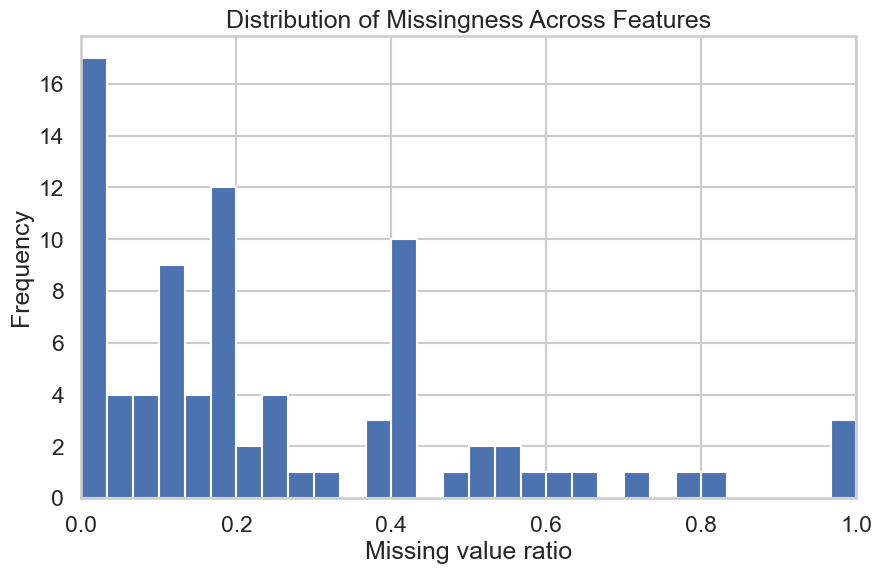

In [49]:
missing_ratio = merged_dataset.isna().mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
missing_ratio.plot(kind="hist", bins=30)
plt.xlabel("Missing value ratio")
plt.xlim([0.0, 1.0])
plt.title("Distribution of Missingness Across Features")
plt.show()

### 3.2.1 Missingness Matrix for Features over Time

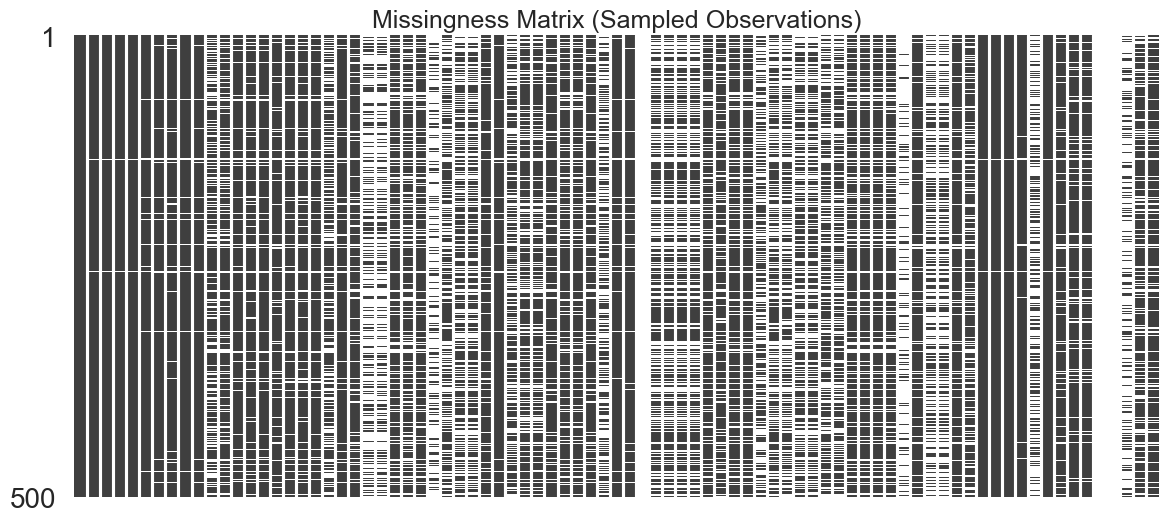

In [50]:
msno_matrix(
    merged_dataset.sort_values(by=['YEAR']).drop(columns=config.info_columns).sample(min(len(worldbank_df), 500)),
    figsize=(14, 6),
    sparkline=False
)
plt.title("Missingness Matrix (Sampled Observations)")
plt.show()

### 3.2.1 Correlation of Missingness Between Features

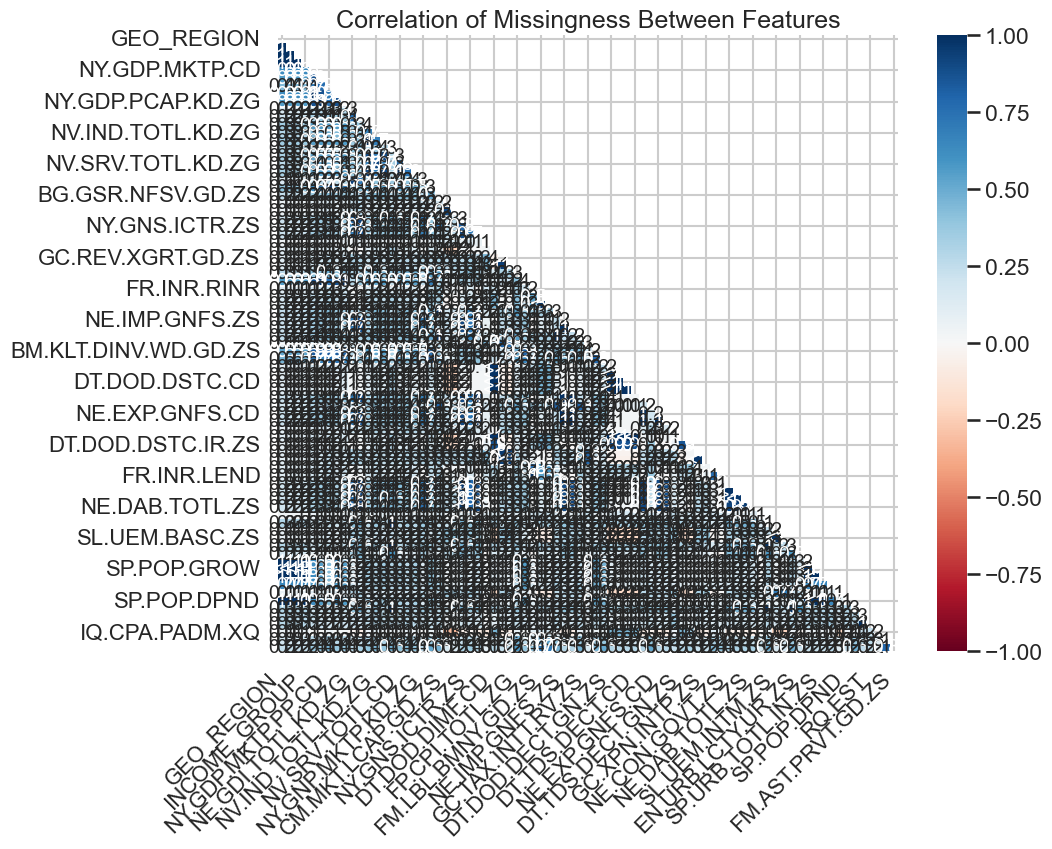

In [51]:
msno_heatmap(merged_dataset, figsize=(10, 8))
plt.title("Correlation of Missingness Between Features")
plt.show()

## 3.3 Coverage by Country Analysis

In [43]:
coverage = merged_dataset.groupby("ISO3_COUNTRY_CODE") \
.apply(lambda x: x.notna().mean().mean()) \
.sort_values()

/var/folders/z6/32ll3t5d46q7xhp0hcl2wpww0000gn/T/ipykernel_4728/818459852.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  coverage = merged_dataset.groupby("ISO3_COUNTRY_CODE") \


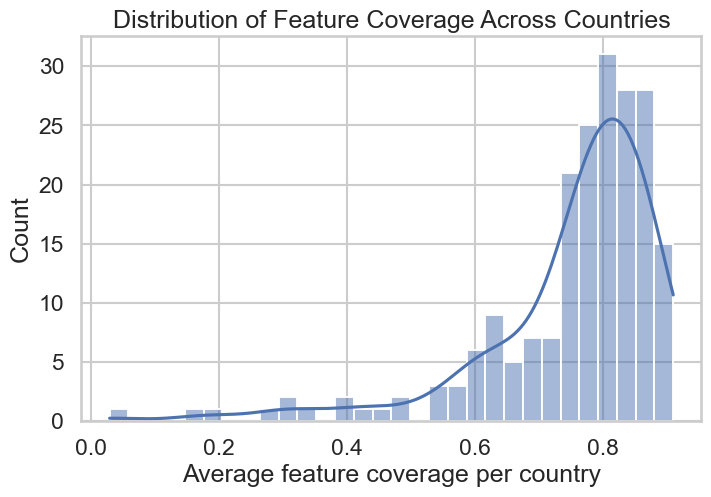

In [44]:
plt.figure(figsize=(8, 5))
sns.histplot(coverage, bins=30, kde=True)
plt.xlabel("Average feature coverage per country")
plt.title("Distribution of Feature Coverage Across Countries")
plt.show()

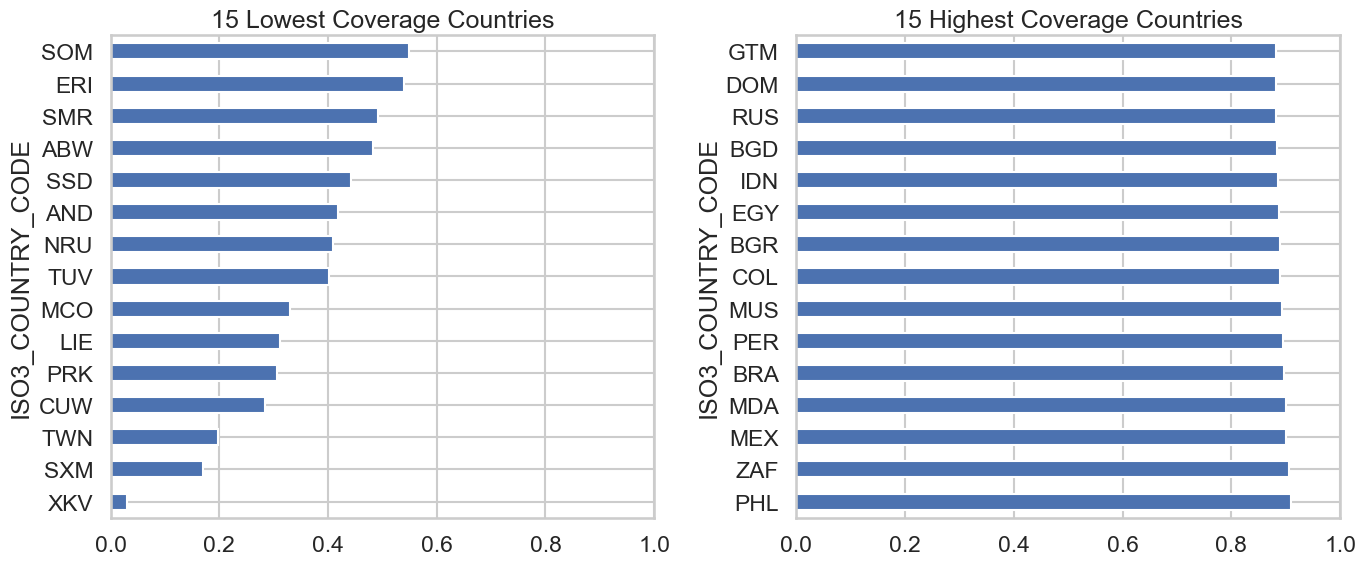

In [56]:
N = 15

worst = coverage.nsmallest(N)
best = coverage.nlargest(N)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))


worst.plot(kind="barh", ax=axes[0])
axes[0].set_title(f"{N} Lowest Coverage Countries")
axes[0].set_xlim([0.0, 1.0])

best.plot(kind="barh", ax=axes[1])
axes[1].set_title(f"{N} Highest Coverage Countries")
axes[1].set_xlim([0.0, 1.0])

plt.tight_layout()
plt.show()

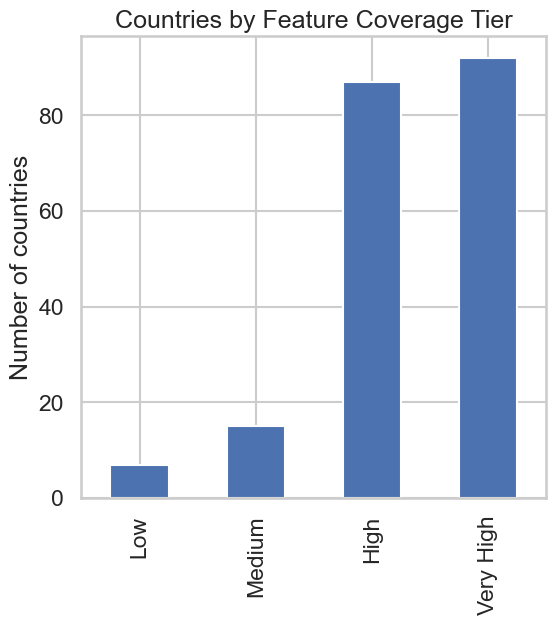

In [57]:
coverage_bins = pd.cut(
    coverage,
    bins=[0, 0.4, 0.6, 0.8, 1.0],
    labels=["Low", "Medium", "High", "Very High"]
)

coverage_summary = coverage_bins.value_counts().sort_index()

plt.figure(figsize=(6, 6))
coverage_summary.plot(kind="bar")
plt.ylabel("Number of countries")
plt.title("Countries by Feature Coverage Tier")
plt.show()